In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"E:\Internshala\Course 6 Machine Learning\Project\Target.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   620 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

In [4]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 5:20:57 PM GMT+5:30,24,Others,Once a month,Clothing and Fashion;others,No,Rarely,Keyword,First page,1,...,No,Heavily,Yes,4,Sometimes,2,1,Customer service,I don't have any problem with Amazon,567877
1,2023/06/12 2:44:47 PM GMT+5:30,12,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,categories,First page,5,...,Yes,Occasionally,Yes,4,Sometimes,5,3,Competitive prices,Nil,313221
2,2023/06/09 2:39:16 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion;Home and Kitchen,No,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Rarely,Sometimes,2,Yes,3,2,.,I have no problem with Amazon yet. But others ...,532959
3,2023/06/08 7:33:15 AM GMT+5:30,51,Female,Multiple times a week,Beauty and Personal Care;Clothing and Fashion;...,No,Multiple times a day,categories,First page,1,...,No,Never,Sometimes,4,Sometimes,1,4,Product recommendations,Irrelevant product suggestions,310717
4,2023/06/11 11:01:04 PM GMT+5:30,46,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Keyword,First page,4,...,No,Rarely,Yes,3,No,2,5,Product recommendations,Add more familiar brands to the list,661323


In [5]:
df.shape

(800, 24)

# Task 1: Data Cleaning and Preparation 

## Task 1.1: Remove duplicate or inconsistent survey responses. 

In [6]:
df.duplicated().sum()

np.int64(0)

## Task 1.2: Standardize categorical/numerical entries (e.g., frequency levels, gender, recommendation responses). 

In [7]:
df['Search_Result_Exploration'].value_counts()

Search_Result_Exploration
First page        418
Multiple pages    382
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male                 214
Female               201
Others               196
Prefer not to say    189
Name: count, dtype: int64

In [9]:
df['Purchase_Frequency'].value_counts()

Purchase_Frequency
Multiple times a week     173
Less than once a month    168
Once a month              164
Few times a month         153
Once a week               142
Name: count, dtype: int64

#### standardizing the frequency levels 

In [10]:
df['Purchase_Frequency'] = df['Purchase_Frequency'].replace({
    'Once a week': 'weekly',
    'Multiple times a week': 'weekly_high',
    'Less than once a month': 'Quarterly',
    'Once a month': 'monthly',
    'Few times a month': 'monthly_high'
})

In [11]:
df['Purchase_Frequency'].value_counts()

Purchase_Frequency
weekly_high     173
Quarterly       168
monthly         164
monthly_high    153
weekly          142
Name: count, dtype: int64

In [12]:
df['Personalized_Recommendation_Frequency'].value_counts()

Personalized_Recommendation_Frequency
No           271
Yes          271
Sometimes    258
Name: count, dtype: int64

In [13]:
df['Browsing_Frequency'].value_counts()

Browsing_Frequency
Multiple times a day    207
Rarely                  200
Few times a month       197
Few times a week        196
Name: count, dtype: int64

#### Naming 'Multiple times a day' as 'High', 'Rarely'as 'Rarely', 'Few times a month'as'low' and 'Few times a week' as 'moderate'.

In [14]:
df['Browsing_Frequency']= df['Browsing_Frequency'].replace({ 
    'Multiple times a day':'High',
    'Rarely': 'Rarely',
    'Few times a month':'low',
    'Few times a week': 'moderate'
})
df['Browsing_Frequency'].value_counts()

Browsing_Frequency
High        207
Rarely      200
low         197
moderate    196
Name: count, dtype: int64

In [15]:
df['Recommendation_Helpfulness'].value_counts()

Recommendation_Helpfulness
Sometimes    270
Yes          265
No           265
Name: count, dtype: int64

In [16]:
df['Recommendation_Helpfulness_Score'] = df['Recommendation_Helpfulness'].str.strip().str.lower()
mapping = {
    'yes': 1,
    'sometimes': 2,
    'no': 0
}
df['Recom_Helpfulness_Score'] = df['Recommendation_Helpfulness_Score'].map(mapping)
df['Recom_Helpfulness_Score'].value_counts()

Recom_Helpfulness_Score
2    270
1    265
0    265
Name: count, dtype: int64

## Task 1.3: Handle missing values and inconsistent formats in Product_Search_Method and other fields. 

In [17]:
df.isnull().sum()

Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     180
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction                       0
Service_Appreciation              

In [18]:
df['Product_Search_Method'].fillna(df['Product_Search_Method'].mode()[0], inplace=True)

C:\Users\alpan\AppData\Local\Temp\ipykernel_28236\3407113432.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product_Search_Method'].fillna(df['Product_Search_Method'].mode()[0], inplace=True)


In [19]:
df.isnull().sum()

Timestamp                                 0
age                                       0
Gender                                    0
Purchase_Frequency                        0
Purchase_Categories                       0
Personalized_Recommendation_Frequency     0
Browsing_Frequency                        0
Product_Search_Method                     0
Search_Result_Exploration                 0
Customer_Reviews_Importance               0
Add_to_Cart_Browsing                      0
Cart_Completion_Frequency                 0
Cart_Abandonment_Factors                  0
Saveforlater_Frequency                    0
Review_Left                               0
Review_Reliability                        0
Review_Helpfulness                        0
Personalized_Recommendation_Frequency     0
Recommendation_Helpfulness                0
Rating_Accuracy                           0
Shopping_Satisfaction                     0
Service_Appreciation                      0
Improvement_Areas               

In [20]:
df['Service_Appreciation'].value_counts()

Service_Appreciation
User-friendly website/app interface    105
Competitive prices                     100
Wide product selection                  98
Customer service                        90
Product recommendations                 85
.                                       85
All the above                           83
Customer service                        82
Quick delivery                          72
Name: count, dtype: int64

#### Service appreciation has some data with no name so replaced it with mode value

In [21]:
df['Service_Appreciation'] = df['Service_Appreciation'].replace(df['Service_Appreciation'].mode())
df['Service_Appreciation'].value_counts()

Service_Appreciation
User-friendly website/app interface    105
Competitive prices                     100
Wide product selection                  98
Customer service                        90
Product recommendations                 85
.                                       85
All the above                           83
Customer service                        82
Quick delivery                          72
Name: count, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   800 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

## Task 1.4: Rename duplicate or misformatted columns (e.g., remove trailing spaces in Rating_Accuracy ). 

In [23]:
df.columns=['Timestamp','Age','Gender','Purchase_freq', 'Purchase_cat',
            'Personalized_recom_freq(cat)','Browse_freq','Product_Search_Method',
            'Search_Result_Exploration','Customer_Reviews_Imp','Add_to_Cart_Brows',
            'Cart_Completion_Freq', 'Cart_Abandon_Factors', 'Save_for_later_Freq',
            'Review_Left','Review_Reliability', 'Review_Helpfulness','Personalized_Recom_Freq(num)',
            'Recom_Helpfulness','Rating_Accuracy','Shopping_Satisfaction','Service_Appreciation','Improvement_Areas','transaction',
            'Recommendation_Helpfulness_Score','Recom_Helpfulness_Score']
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Purchase_freq', 'Purchase_cat',
       'Personalized_recom_freq(cat)', 'Browse_freq', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Imp',
       'Add_to_Cart_Brows', 'Cart_Completion_Freq', 'Cart_Abandon_Factors',
       'Save_for_later_Freq', 'Review_Left', 'Review_Reliability',
       'Review_Helpfulness', 'Personalized_Recom_Freq(num)',
       'Recom_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction',
       'Service_Appreciation', 'Improvement_Areas', 'transaction',
       'Recommendation_Helpfulness_Score', 'Recom_Helpfulness_Score'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Timestamp                         800 non-null    object
 1   Age                               800 non-null    int64 
 2   Gender                            800 non-null    object
 3   Purchase_freq                     800 non-null    object
 4   Purchase_cat                      800 non-null    object
 5   Personalized_recom_freq(cat)      800 non-null    object
 6   Browse_freq                       800 non-null    object
 7   Product_Search_Method             800 non-null    object
 8   Search_Result_Exploration         800 non-null    object
 9   Customer_Reviews_Imp              800 non-null    int64 
 10  Add_to_Cart_Brows                 800 non-null    object
 11  Cart_Completion_Freq              800 non-null    object
 12  Cart_Abandon_Factors  

## Task 1.5: Convert numerical rating columns (e.g., Customer_Reviews_Importance, Shopping_Satisfaction) to appropriate numeric types for analysis. 

In [25]:
df['Customer_Reviews_Imp'].value_counts()

Customer_Reviews_Imp
5    171
2    163
1    161
3    159
4    146
Name: count, dtype: int64

In [26]:
df['Shopping_Satisfaction'].value_counts()

Shopping_Satisfaction
1    173
2    167
5    166
3    165
4    129
Name: count, dtype: int64

# Task 2: Descriptive Behavior Analysis 

## Task 2.1: Summarize customer demographics (age, gender distribution).

In [27]:
# Age 
df['Age'].describe()

count    800.000000
mean      34.737500
std       18.938306
min        3.000000
25%       18.000000
50%       34.000000
75%       50.250000
max       67.000000
Name: Age, dtype: float64

In [28]:
bins = [0,10,20,30,40,50,60,70]
age_labels=['0-10','11-20','21-30','31-40','41-50','51-60','61-70']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=age_labels, right =True)

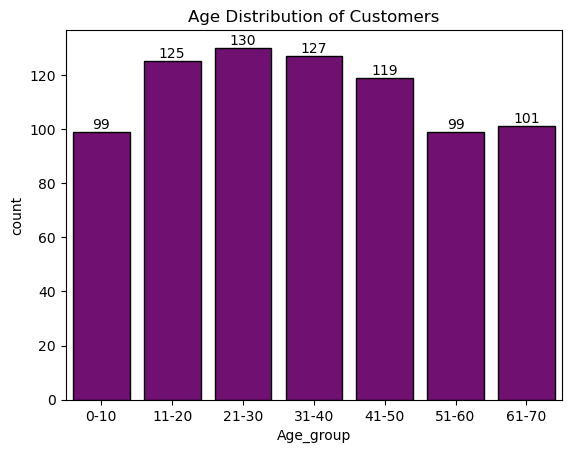

In [29]:
ag=sns.countplot(x='Age_group', data=df, order=age_labels, color='purple',edgecolor='black')
ag.bar_label(ag.containers[0])
plt.xlabel("Age_group")
plt.title("Age Distribution of Customers")
plt.xticks(rotation=0)
plt.show()

#### --> It is indicated from the bar graph that the majority of customers are younger that is between 21-30 age group.

In [30]:
df['Gender'].value_counts()

Gender
Male                 214
Female               201
Others               196
Prefer not to say    189
Name: count, dtype: int64

In [31]:
df['Gender'].value_counts(normalize=True) * 100

Gender
Male                 26.750
Female               25.125
Others               24.500
Prefer not to say    23.625
Name: proportion, dtype: float64

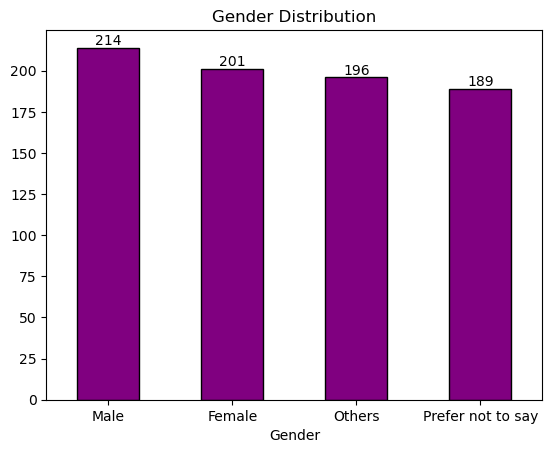

In [32]:
gd=df['Gender'].value_counts().plot(kind='bar', title='Gender Distribution', color='purple',edgecolor='black')
gd.bar_label(gd.containers[0])
plt.xticks(rotation=0) 
plt.show()

#### --> The gender distribution shows a higher number of male customers compared to female and other categories, indicating a slight dominance of male users in the dataset.

### Then we check for any outliers in the numerical data 

In [33]:
num_cols= df.dtypes[df.dtypes!=object].index
num_cols

Index(['Age', 'Customer_Reviews_Imp', 'Personalized_Recom_Freq(num)',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'transaction',
       'Recom_Helpfulness_Score', 'Age_group'],
      dtype='object')

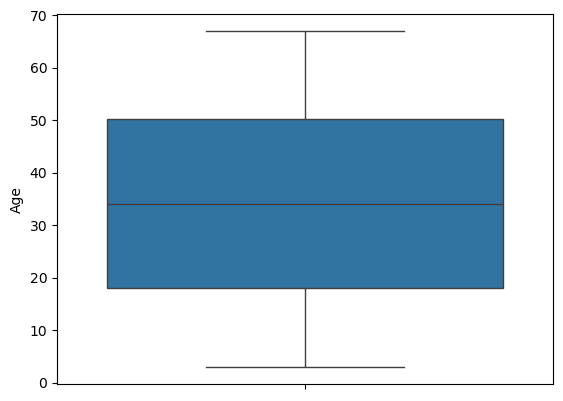

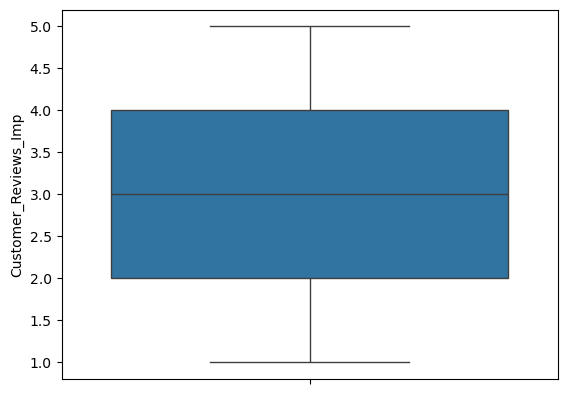

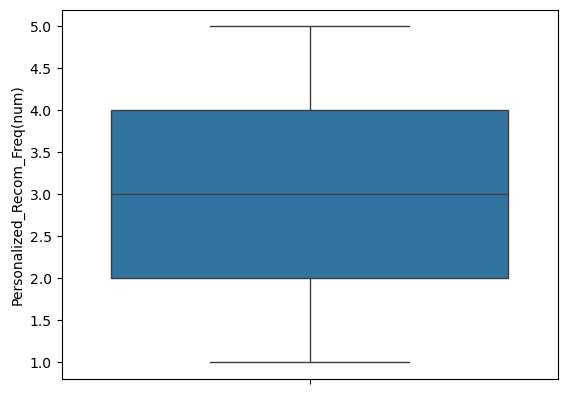

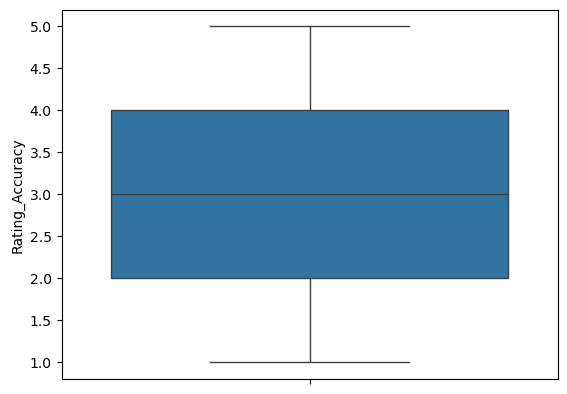

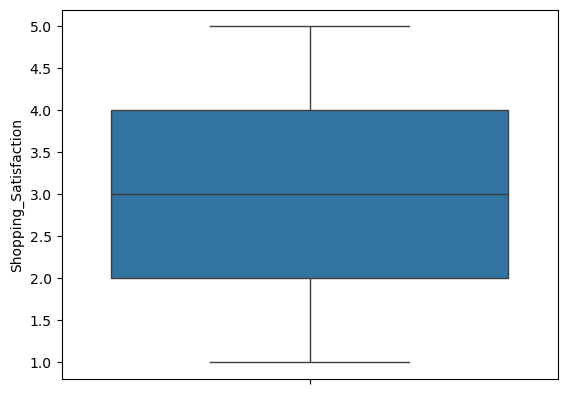

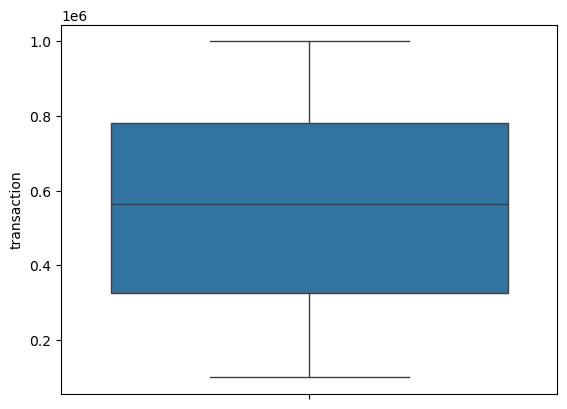

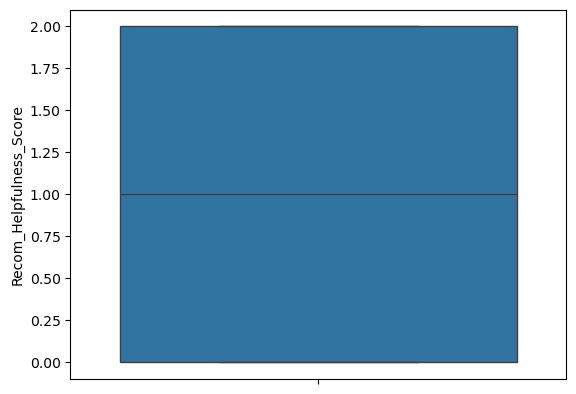

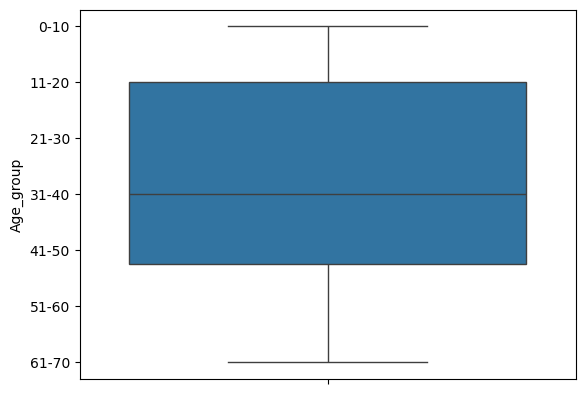

In [34]:
for cols in num_cols:
    sns.boxplot(y=df[cols])
    plt.show()

In [35]:
cat_cols=df.dtypes[df.dtypes==object].index
cat_cols

Index(['Timestamp', 'Gender', 'Purchase_freq', 'Purchase_cat',
       'Personalized_recom_freq(cat)', 'Browse_freq', 'Product_Search_Method',
       'Search_Result_Exploration', 'Add_to_Cart_Brows',
       'Cart_Completion_Freq', 'Cart_Abandon_Factors', 'Save_for_later_Freq',
       'Review_Left', 'Review_Reliability', 'Review_Helpfulness',
       'Recom_Helpfulness', 'Service_Appreciation', 'Improvement_Areas',
       'Recommendation_Helpfulness_Score'],
      dtype='object')

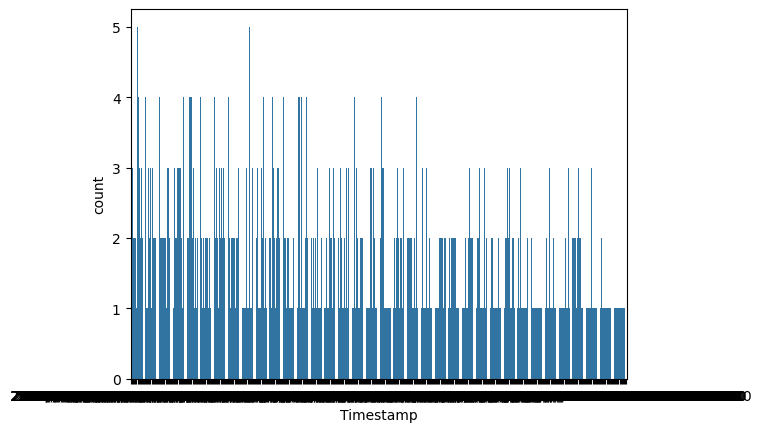

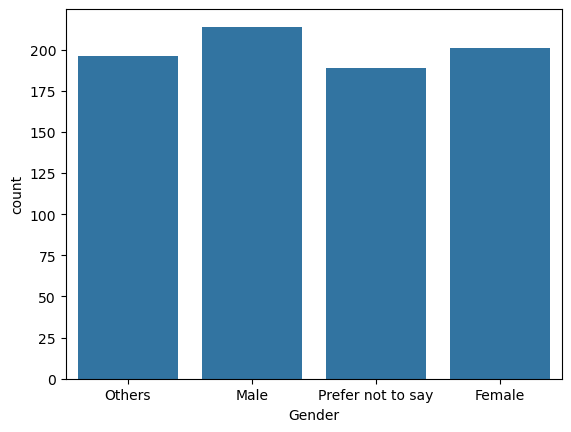

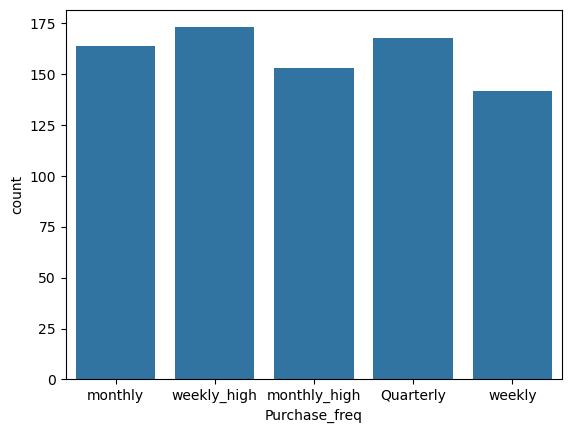

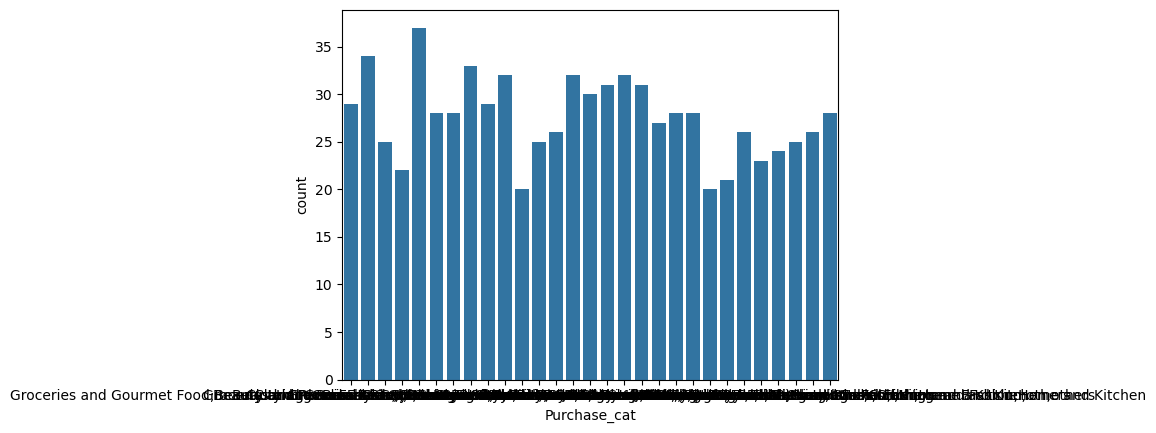

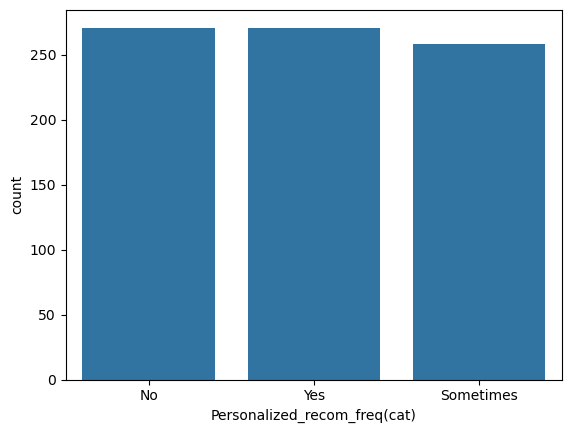

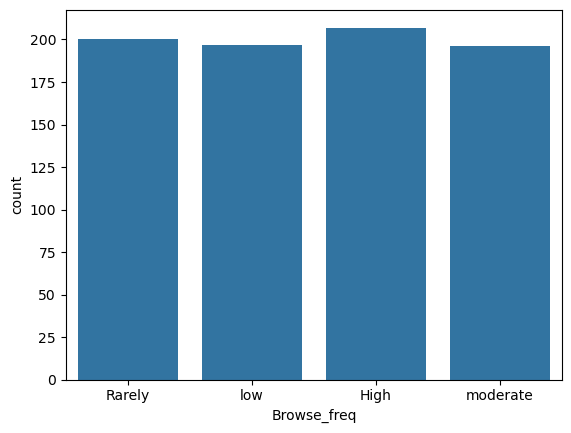

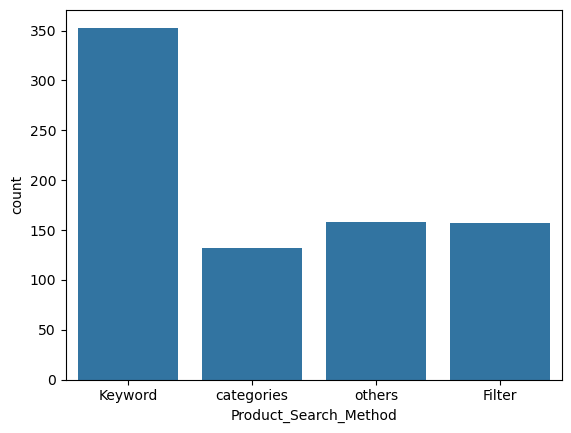

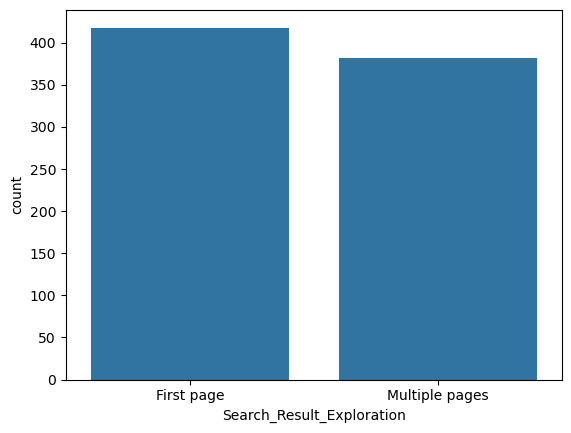

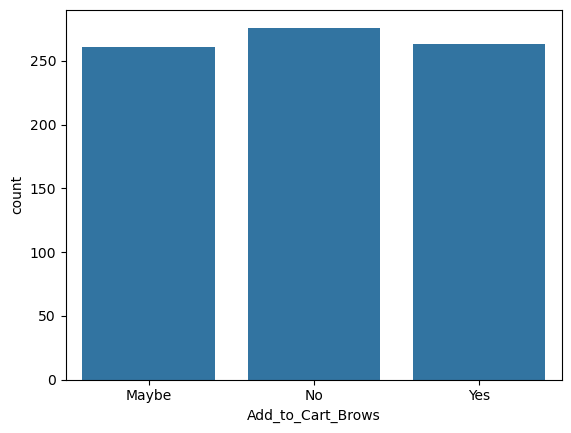

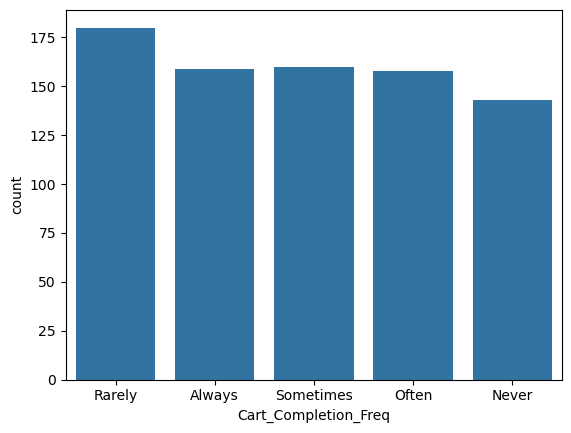

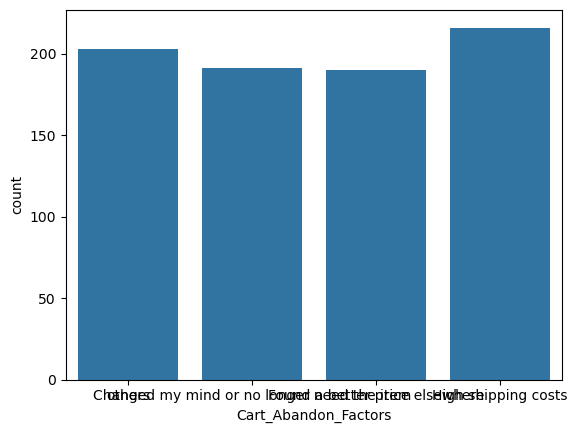

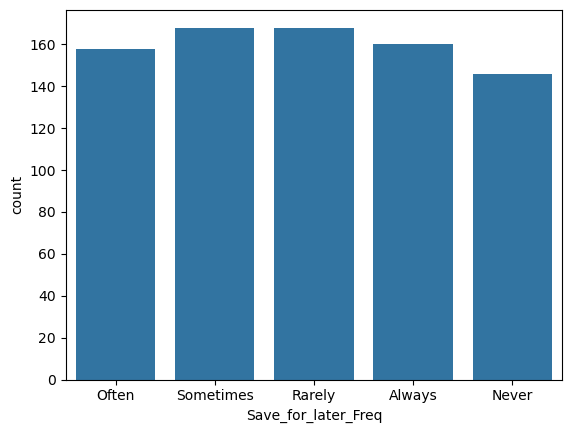

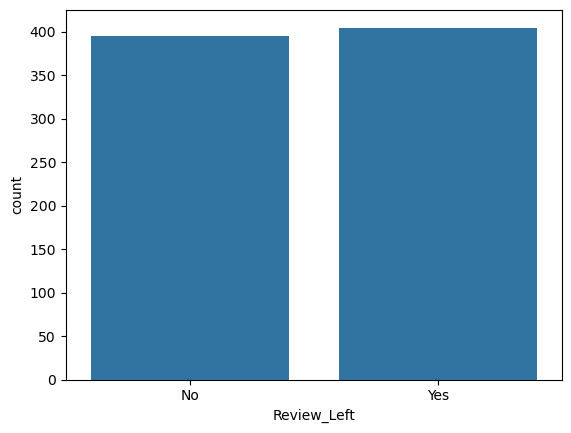

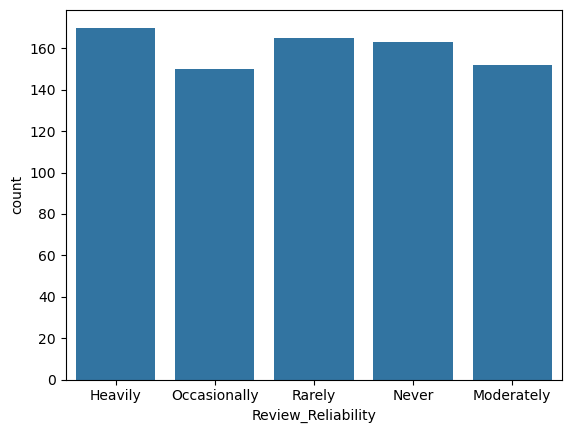

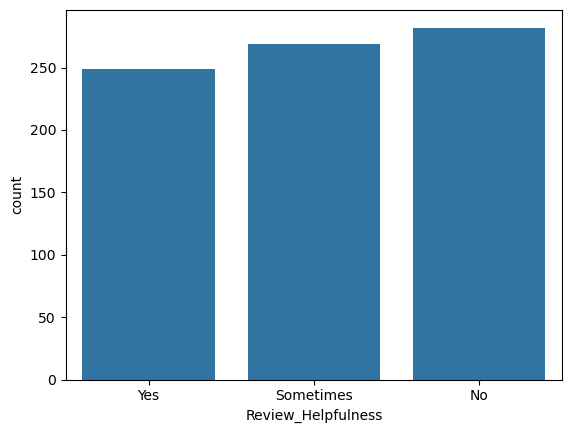

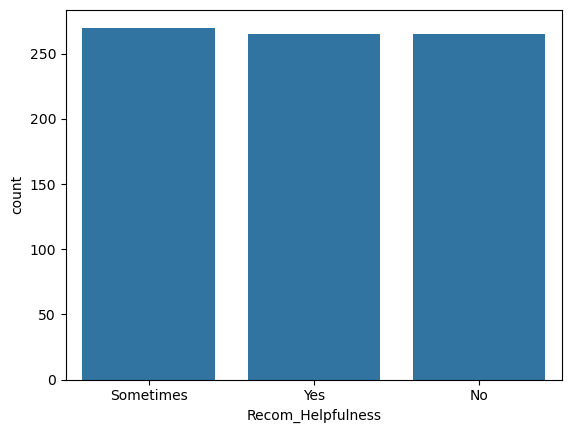

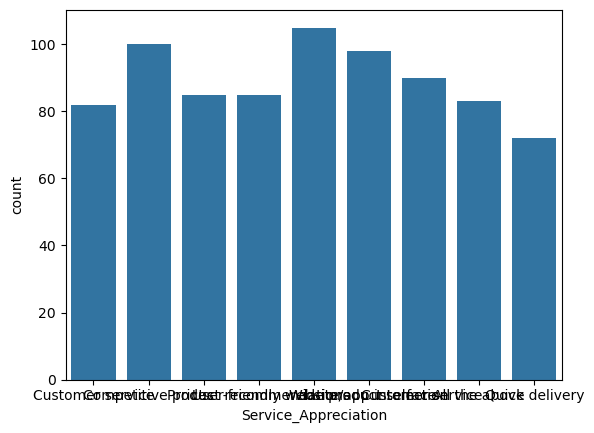

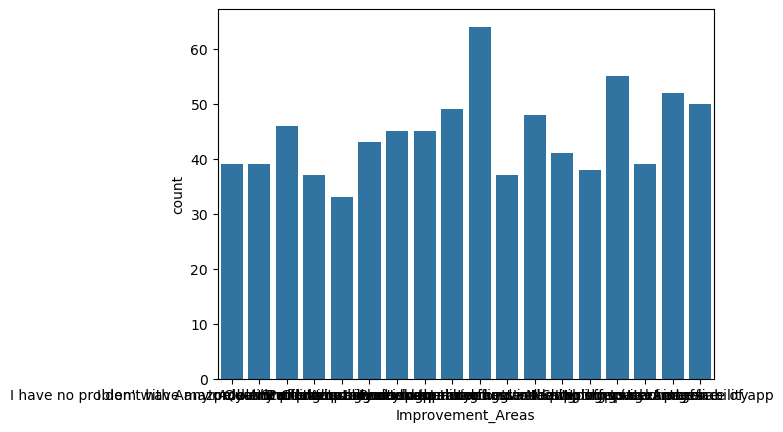

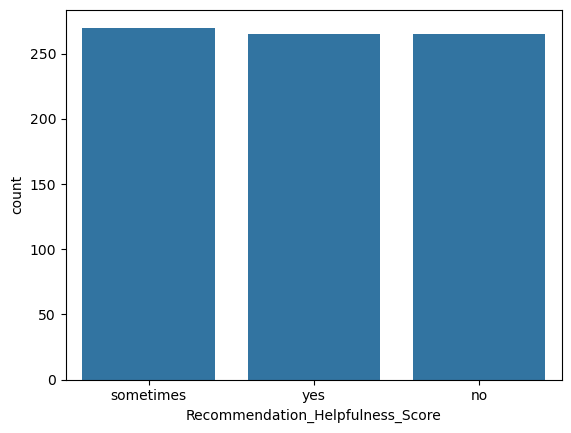

In [36]:
for i in cat_cols:
    sns.countplot(x=df[i])
    plt.yticks(fontsize=10)
    plt.show()

### Remove unnecessary columns which are not required in the analysis.

In [37]:
df.drop(columns=['Timestamp','transaction',], inplace=True)

In [38]:
df.columns

Index(['Age', 'Gender', 'Purchase_freq', 'Purchase_cat',
       'Personalized_recom_freq(cat)', 'Browse_freq', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Imp',
       'Add_to_Cart_Brows', 'Cart_Completion_Freq', 'Cart_Abandon_Factors',
       'Save_for_later_Freq', 'Review_Left', 'Review_Reliability',
       'Review_Helpfulness', 'Personalized_Recom_Freq(num)',
       'Recom_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction',
       'Service_Appreciation', 'Improvement_Areas',
       'Recommendation_Helpfulness_Score', 'Recom_Helpfulness_Score',
       'Age_group'],
      dtype='object')

## Task 2.2: Analyze overall purchase frequency and most popular product categories.

In [39]:
# Purchase frequency
df['Purchase_freq'].value_counts()

Purchase_freq
weekly_high     173
Quarterly       168
monthly         164
monthly_high    153
weekly          142
Name: count, dtype: int64

In [40]:
# Product categories
df['Purchase_cat'].value_counts()

Purchase_cat
Groceries and Gourmet Food;Beauty and Personal Care;others                                          37
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others    34
Home and Kitchen                                                                                    33
Groceries and Gourmet Food;Beauty and Personal Care                                                 32
Groceries and Gourmet Food;Clothing and Fashion;others                                              32
Beauty and Personal Care;Clothing and Fashion                                                       32
Beauty and Personal Care;Home and Kitchen                                                           31
Groceries and Gourmet Food                                                                          31
others                                                                                              30
Beauty and Personal Care;Clothing and Fashion;Home and Kitch

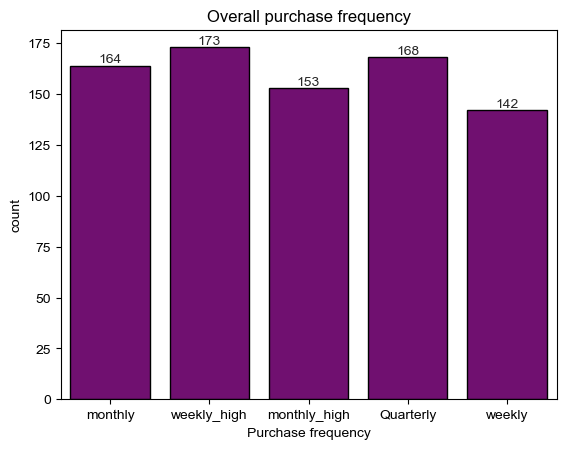

<Figure size 800x200 with 0 Axes>

In [41]:
pf=sns.countplot(x='Purchase_freq', data=df, color = 'purple', edgecolor = 'black')
plt.xlabel('Purchase frequency')
plt.title('Overall purchase frequency')
sns.set_style("whitegrid")
plt.figure(figsize=(8,2))
pf.bar_label(pf.containers[0])
plt.show()

### --> It is clearly visible that weekly_high that is multiple times a week products are purchased. 

In [42]:
# For purchase category
df['Purchase_cat'].value_counts()

Purchase_cat
Groceries and Gourmet Food;Beauty and Personal Care;others                                          37
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others    34
Home and Kitchen                                                                                    33
Groceries and Gourmet Food;Beauty and Personal Care                                                 32
Groceries and Gourmet Food;Clothing and Fashion;others                                              32
Beauty and Personal Care;Clothing and Fashion                                                       32
Beauty and Personal Care;Home and Kitchen                                                           31
Groceries and Gourmet Food                                                                          31
others                                                                                              30
Beauty and Personal Care;Clothing and Fashion;Home and Kitch

In [43]:
df_splitted = df.assign(Purchase_cat=df['Purchase_cat'].str.split(';')).explode('Purchase_cat')
df_splitted['Purchase_cat'].value_counts()

Purchase_cat
Beauty and Personal Care      426
Clothing and Fashion          424
Home and Kitchen              406
Groceries and Gourmet Food    403
others                        384
Name: count, dtype: int64

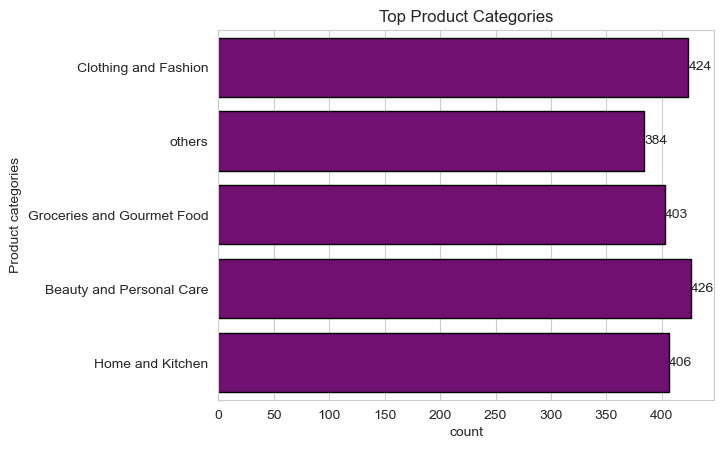

In [44]:
pc=sns.countplot(y='Purchase_cat',data=df_splitted, color='purple', edgecolor='black')
pc.bar_label(pc.containers[0])
plt.ylabel('Product categories')
plt.title("Top Product Categories")
plt.show()

#### --> Beauty and Personal care followed by Clothing and fashion are the most frequently purchased categories, indicating strong customer interest in these segments.

## Task 2.3: Identify top browsing methods and most common cart abandonment factors.

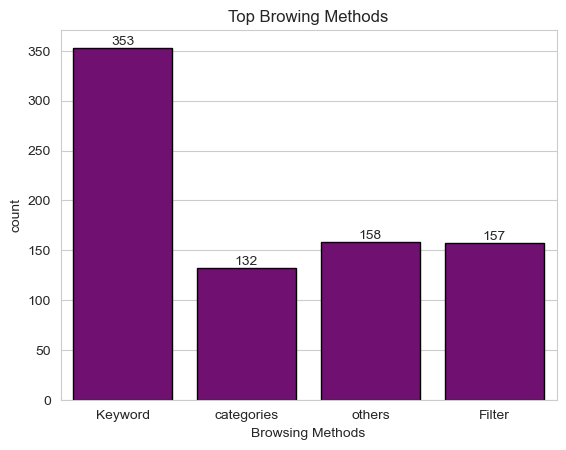

<Figure size 800x500 with 0 Axes>

In [45]:
psm=sns.countplot(x='Product_Search_Method', data=df, color = 'purple', edgecolor = 'black')
plt.xlabel('Browsing Methods')
plt.title('Top Browing Methods')
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
psm.bar_label(psm.containers[0])
plt.show()

### --> Keyword is the most used browsing method.

In [46]:
df['Cart_Abandon_Factors'].value_counts()

Cart_Abandon_Factors
High shipping costs                           216
others                                        203
Changed my mind or no longer need the item    191
Found a better price elsewhere                190
Name: count, dtype: int64

In [47]:
df['Cart_Abandon_Factors'] = df['Cart_Abandon_Factors'].str.strip().str.lower()

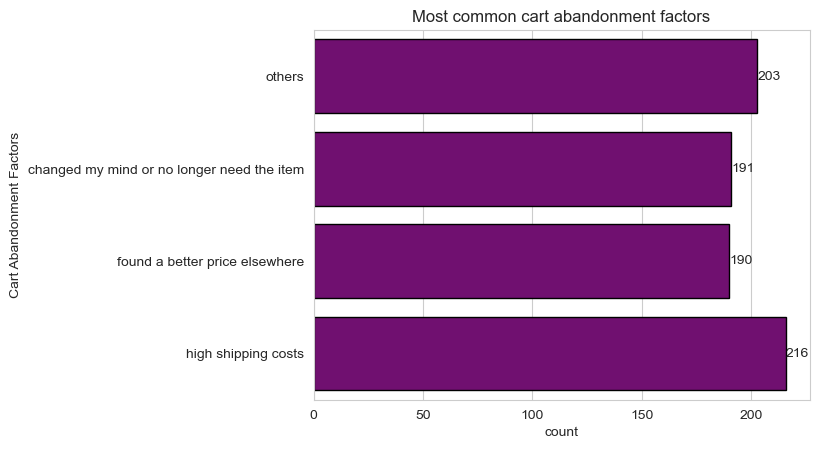

In [48]:
caf=sns.countplot(y='Cart_Abandon_Factors', data=df, color = 'purple', edgecolor = 'black')
plt.ylabel('Cart Abandonment Factors')
plt.title('Most common cart abandonment factors')
plt.yticks(rotation=0)
sns.set_style("whitegrid")
caf.bar_label(caf.containers[0])
plt.show()

### --> High shipping costs is the main factor for cart abandonment.

## Task 2.4: Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy. 

In [49]:
df[['Shopping_Satisfaction','Recom_Helpfulness','Rating_Accuracy']].dtypes

Shopping_Satisfaction     int64
Recom_Helpfulness        object
Rating_Accuracy           int64
dtype: object

In [50]:
df['Recom_Helpfulness'].mode()

0    Sometimes
Name: Recom_Helpfulness, dtype: object

In [51]:
df[['Shopping_Satisfaction', 
    'Rating_Accuracy']].agg(['mean', 'median'])

,Shopping_Satisfaction,Rating_Accuracy
mean,2.935,3.05875
median,3.000,3.00000


## Task 2.5: Generate summary statistics and visualizations for key behavioral variables. 

#### Behavioral columns 

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Age                               800 non-null    int64   
 1   Gender                            800 non-null    object  
 2   Purchase_freq                     800 non-null    object  
 3   Purchase_cat                      800 non-null    object  
 4   Personalized_recom_freq(cat)      800 non-null    object  
 5   Browse_freq                       800 non-null    object  
 6   Product_Search_Method             800 non-null    object  
 7   Search_Result_Exploration         800 non-null    object  
 8   Customer_Reviews_Imp              800 non-null    int64   
 9   Add_to_Cart_Brows                 800 non-null    object  
 10  Cart_Completion_Freq              800 non-null    object  
 11  Cart_Abandon_Factors              800 non-null    object  

In [53]:
freq_map = {
    'weekly_high': 1,
    'weekly': 2,
    'monthly_high': 3,
    'monthly': 4,
    'Quarterly': 5
}

df['Purchase_freq_score'] = df['Purchase_freq'].map(freq_map)
df['Purchase_freq_score']

0      4
1      1
2      3
3      1
4      1
      ..
795    2
796    4
797    5
798    2
799    2
Name: Purchase_freq_score, Length: 800, dtype: int64

In [54]:
behavior_cols = df[['Purchase_freq_score','Personalized_Recom_Freq(num)','Rating_Accuracy','Shopping_Satisfaction']].describe()
behavior_cols

,Purchase_freq_score,Personalized_Recom_Freq(num),Rating_Accuracy,Shopping_Satisfaction
count,800.000000,800.000000,800.000000,800.000000
mean,3.015000,2.981250,3.058750,2.935000
std,1.445644,1.450354,1.439753,1.436438
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


#### Summary statistics were generated for key behavioral variables to understand central tendency and variability in customer purchase frequency, satisfaction, and engagement patterns.


### Visualizations

### Purchase Frequency

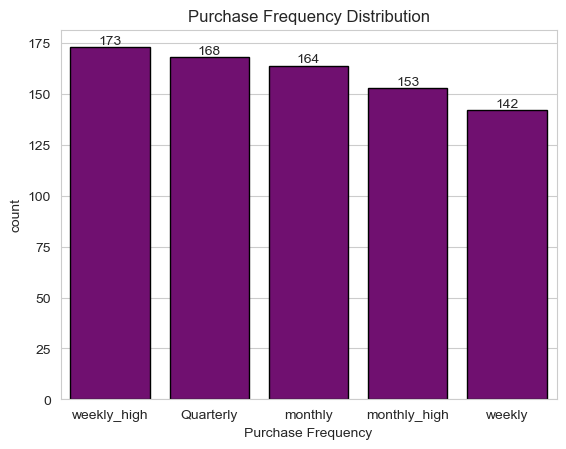

In [55]:
ab=sns.countplot(x='Purchase_freq', data=df, order=df['Purchase_freq'].value_counts().index,color = 'purple', edgecolor='black')
ab.bar_label(ab.containers[0])
plt.xlabel('Purchase Frequency')
plt.title("Purchase Frequency Distribution")
plt.xticks(rotation=0)
plt.show()

#### --> Most customers fall under weekly_high (173), which indicates high engagement, weekly(142) is lowest that is fewer low-frequency users. Overall, users are skewed toward higher purchase frequency, suggesting strong customer activity.

### Browsing Frequency

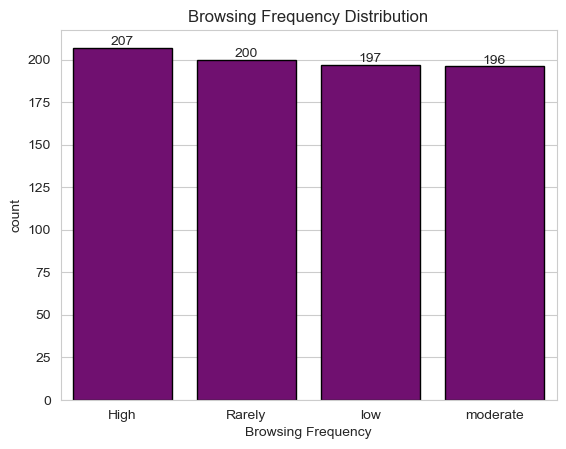

In [56]:
ac=sns.countplot(x='Browse_freq', data=df, order=df['Browse_freq'].value_counts().index,color = 'purple', edgecolor='black')
ac.bar_label(ac.containers[0])
plt.xlabel('Browsing Frequency')
plt.title("Browsing Frequency Distribution")
plt.xticks(rotation=0)
plt.show()

#### --> Customers which are browsing daily are highest (207) in number and customers who browse few times in a week or in a month are lowest around 197 and 196.

### I used a pie chart to represent the distribution of cart completion frequency, making it easier to interpret proportional differences across categories.

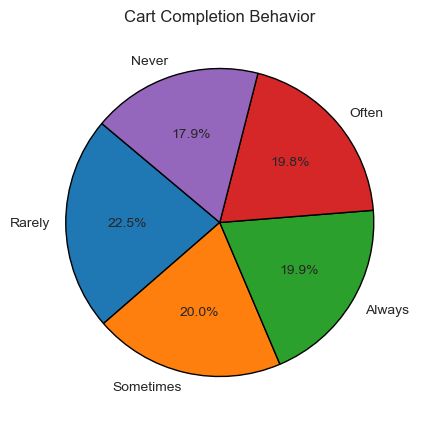

In [57]:
cart_counts=df['Cart_Completion_Freq'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(cart_counts,labels=cart_counts.index,autopct='%1.1f%%',startangle=140,wedgeprops={'edgecolor': 'black'})
plt.title("Cart Completion Behavior")
plt.show()

### --> A significant portion of customers complete purchases frequently, while a noticeable segment shows lower completion rates, indicating potential drop-offs in the purchase funnel.

### Product Search Methods 

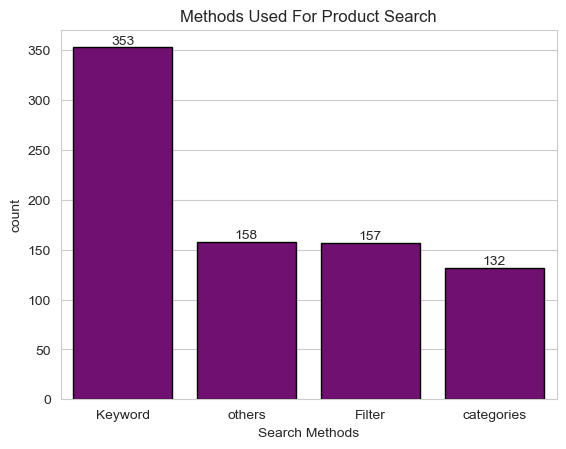

In [58]:
ae= sns.countplot(x='Product_Search_Method', data=df, color = 'purple', edgecolor = 'black', order=df['Product_Search_Method'].value_counts().index)
ae.bar_label(ae.containers[0])
plt.xlabel('Search Methods')
plt.title("Methods Used For Product Search")
plt.show()

#### --> Keyword method (353) is used most frequent than any other search methods and categories being the lowest (132).

### Cart Abandon Factors

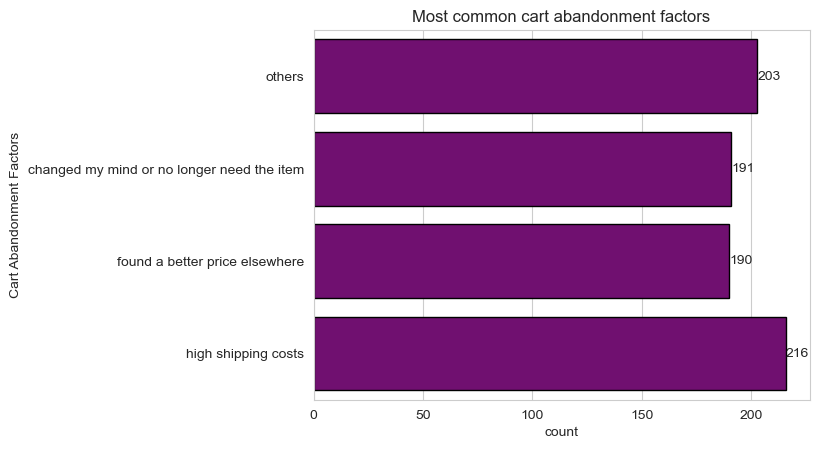

In [59]:
caf=sns.countplot(y='Cart_Abandon_Factors', data=df, color = 'purple', edgecolor = 'black')
plt.ylabel('Cart Abandonment Factors')
plt.title('Most common cart abandonment factors')
plt.yticks(rotation=0)
sns.set_style("whitegrid")
caf.bar_label(caf.containers[0])
plt.show()

#### --> Most of the customers abandon the cart due to its high shipping costs and finding a better price elsewhere is the least cause for cart abandonment.

### •	Heatmap is created for the Shopping satisfaction and rating accuracy to analyse the correlation between the two. 

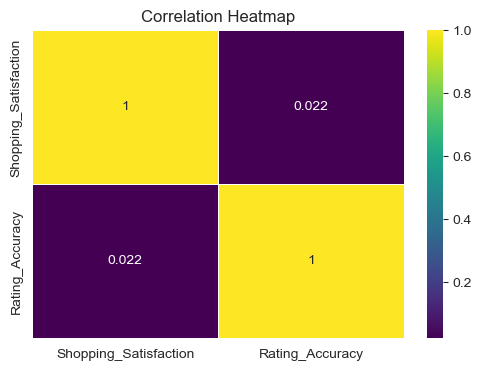

In [60]:
data1 = df[['Shopping_Satisfaction', 'Rating_Accuracy']]
corr = data1.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='viridis', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#### --> The is no relationship betweeen Shopping satisfaction and rating accuracy as the value is near to 0.

### Boxplot for Shopping satisfaction and Rating accuracy to check for the distributions.

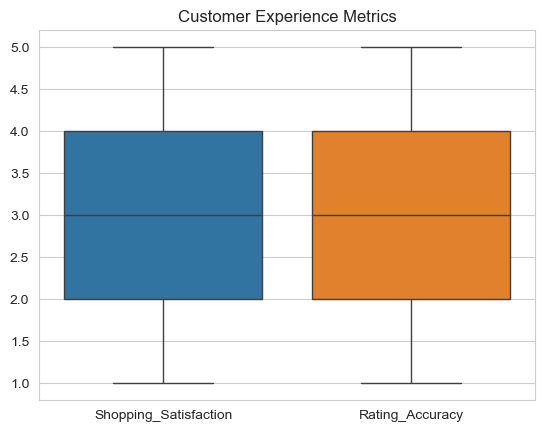

In [61]:
sns.boxplot(data=df[['Shopping_Satisfaction','Rating_Accuracy']])
plt.title("Customer Experience Metrics")
plt.show()

#### --> Both satisfaction and rating accuracy show similar distributions, indicating consistent customer perception across experience and trust metrics.

### Recommendation Helpfulness

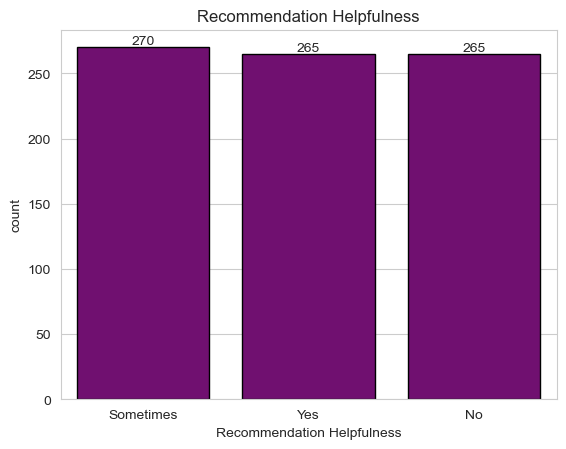

In [62]:
caf=sns.countplot(x='Recom_Helpfulness', data=df, color = 'purple', edgecolor = 'black')
plt.xlabel('Recommendation Helpfulness')
plt.title('Recommendation Helpfulness')
plt.xticks(rotation=0)
sns.set_style("whitegrid")
caf.bar_label(caf.containers[0])
plt.show()

#### --> Almost equal distribution of recommendation helpfullnesss that is recommendation are not really effective.
#### --> Recommendation helpfulness is evenly distributed, indicating that the current recommendation system lacks strong impact and needs optimization.

### Purchase VS Browsing frequency countplot 

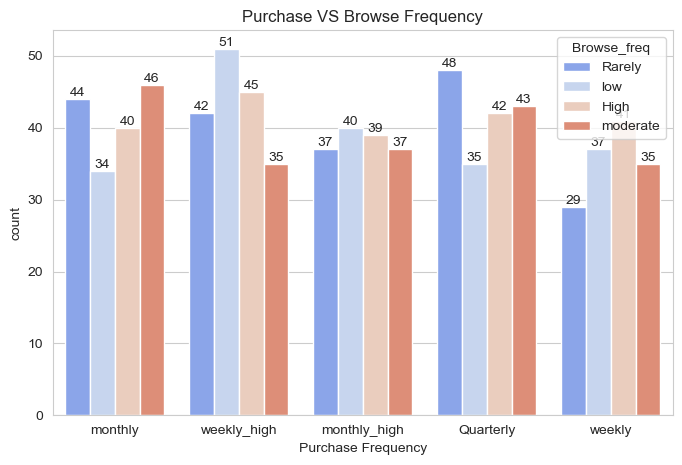

In [63]:
plt.figure(figsize=(8,5))
pvb=sns.countplot(x='Purchase_freq', hue='Browse_freq',data =df, palette='coolwarm')
for container in pvb.containers:
    pvb.bar_label(container)
plt.xlabel('Purchase Frequency')
plt.title('Purchase VS Browse Frequency')
plt.show()

#### --> Users with higher browsing → slightly higher purchase activity
#### --> But pattern is not very strong
#### --> Many users browse frequently but don’t convert consistently

# Task 3: Customer Segmentation and Profiling 

## Task 3.1: Segment customers based on purchase frequency and shopping satisfaction levels. 

In [64]:
df['Purchase_freq'].value_counts()

Purchase_freq
weekly_high     173
Quarterly       168
monthly         164
monthly_high    153
weekly          142
Name: count, dtype: int64

In [65]:
freq_map = {
    'weekly_high': 5,
    'weekly': 4,
    'monthly_high': 3,
    'monthly': 2,
    'Quarterly': 1
}

df['Purchase_freq_score'] = df['Purchase_freq'].map(freq_map)

In [66]:
def segment(row):
    if row['Purchase_freq_score'] == 5 and row['Shopping_Satisfaction'] >= 4:
        return 'Loyal Customers'
    elif row['Purchase_freq_score'] == 4 and row['Shopping_Satisfaction'] < 4:
        return 'Frequent and Satisfied Customers'
    elif row['Purchase_freq_score'] == 3 and row['Shopping_Satisfaction'] >= 3:
        return 'Satisfied but Infrequent Customers'
    elif row['Purchase_freq_score'] == 2 and row['Shopping_Satisfaction'] <2:
        return 'Not Satisfied and Infrequent Customers'
    else:
        return 'Low Value Customers'

df['Customer_Segment'] = df.apply(segment, axis=1)

In [67]:
df['Customer_Segment'].value_counts()

Customer_Segment
Low Value Customers                       535
Frequent and Satisfied Customers           90
Satisfied but Infrequent Customers         87
Loyal Customers                            60
Not Satisfied and Infrequent Customers     28
Name: count, dtype: int64

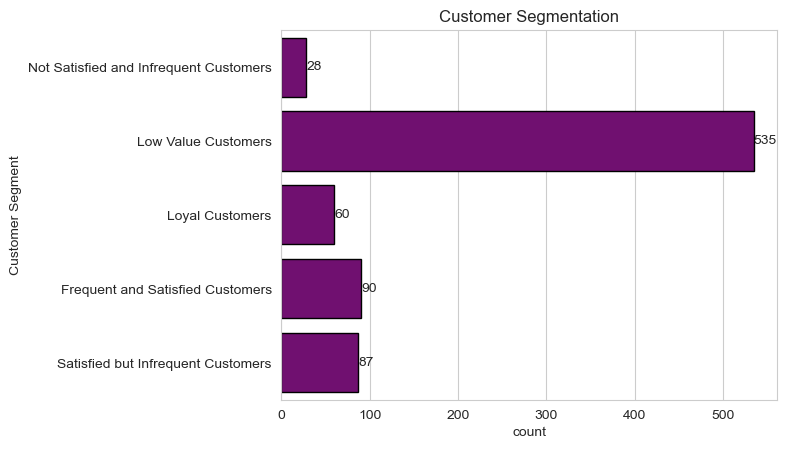

In [68]:
cs=sns.countplot(y='Customer_Segment', data=df, color='purple',edgecolor='black')
cs.bar_label(cs.containers[0])
plt.ylabel('Customer Segment')
plt.title('Customer Segmentation')
plt.show()

#### --> The majority of customers fall under the low-value segment, indicating low engagement levels. 
#### --> However, a significant portion of satisfied but infrequent customers presents an opportunity for conversion into loyal customers through targeted marketing strategies.
#### --> Additionally, the small proportion of dissatisfied customers highlights areas for service improvement to reduce churn.

## Task 3.2: Create profiles such as: 
### ○ Frequent Buyers: High purchase frequency, high satisfaction. 
### ○ Occasional Shoppers: Medium frequency, moderate satisfaction. 
### ○ At-Risk Customers: Low satisfaction or frequent cart abandonment.

In [69]:
df['Cart_Abandon_Factors'].value_counts()

Cart_Abandon_Factors
high shipping costs                           216
others                                        203
changed my mind or no longer need the item    191
found a better price elsewhere                190
Name: count, dtype: int64

In [70]:
cart_map={
    "high shipping costs": 1,
    "others":2,
    "changed my mind or no longer need the item":3,
    "found a better price elsewhere":4
}
df['cart_abandon_score'] = df['Cart_Abandon_Factors'].map(cart_map)

In [71]:
df[['Purchase_freq_score','Shopping_Satisfaction','cart_abandon_score']].describe()

,Purchase_freq_score,Shopping_Satisfaction,cart_abandon_score
count,800.000000,800.000000,800.000000
mean,2.985000,2.935000,2.443750
std,1.445644,1.436438,1.124017
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,1.000000
50%,3.000000,3.000000,2.000000
75%,4.000000,4.000000,3.000000
max,5.000000,5.000000,4.000000


#### --> From the Data distribution, we decide the thresholds as median is nearly equal to 3, where values >= 4 represents high behaviour and <= 2 represents low behaviour. 
#### Frequent Buyers: High purchase frequency >= 4 , high satisfaction >= 4.
#### Occasional Shoppers: Medium frequency is in between 2 and 4, moderate satisfaction is in between 2 and 4.
#### At-Risk Customers: Low satisfaction <=2 or frequent cart abandonment == 1.

In [72]:
def profiles (row):
    if row['Shopping_Satisfaction'] <=2 or row['cart_abandon_score'] == 1:
         return 'At-Risk Customers'
    elif row['Purchase_freq_score'] >=4 and row['Shopping_Satisfaction'] >=4:
        return 'Frequent Buyers'
    elif (2 < row['Purchase_freq_score'] < 4) and (2 < row['Shopping_Satisfaction'] < 4):
        return 'Occasional Buyers'
    else:
        return 'Others'
df['Customer_profiles'] = df.apply(profiles, axis=1)

In [73]:
df['Customer_profiles'].value_counts()

Customer_profiles
At-Risk Customers    475
Others               217
Frequent Buyers       84
Occasional Buyers     24
Name: count, dtype: int64

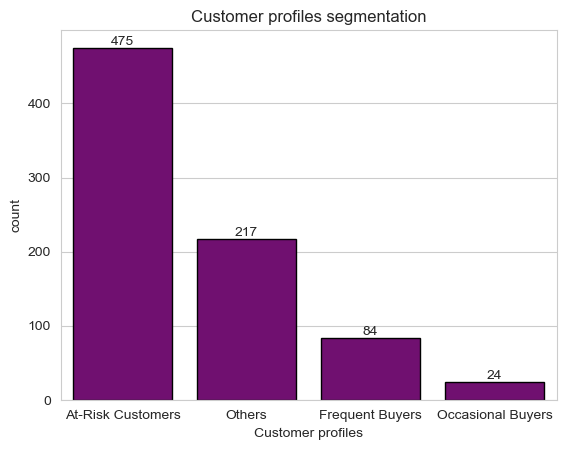

In [74]:
cp=sns.countplot(x='Customer_profiles', data=df, color='purple',edgecolor='black')
cp.bar_label(cp.containers[0])
plt.xlabel('Customer profiles')
plt.title('Customer profiles segmentation')
plt.show()

#### --> Majority of customers are at risk (340) and very few are occassional buyers (28), frequent buyers are also very moderate(112). 

## Task 3.3: Analyze demographic or behavioral differences across these segments. 

### Age Across Customer profiles

In [75]:
df.groupby('Customer_profiles')['Age'].mean()

Customer_profiles
At-Risk Customers    33.650526
Frequent Buyers      36.702381
Occasional Buyers    39.916667
Others               35.783410
Name: Age, dtype: float64

In [76]:
df.groupby('Customer_profiles')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Customer_profiles,,,,,,,,
At-Risk Customers,475.0,33.650526,19.209921,3.0,17.00,33.0,49.00,67.0
Frequent Buyers,84.0,36.702381,19.448282,5.0,19.75,38.5,52.50,67.0
Occasional Buyers,24.0,39.916667,18.735961,5.0,23.00,42.5,55.25,67.0
Others,217.0,35.783410,18.055832,3.0,21.00,34.0,51.00,67.0


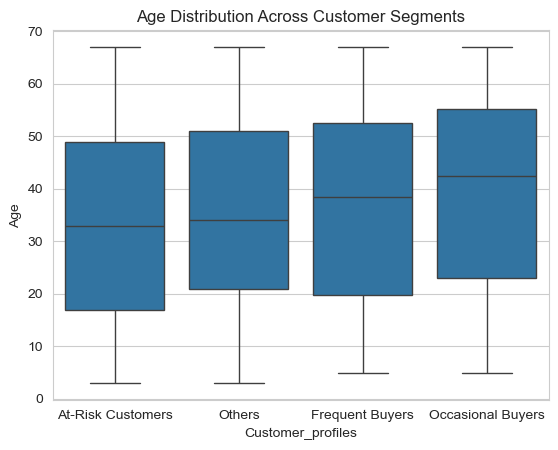

In [77]:
sns.boxplot(x='Customer_profiles', y='Age', data=df)
plt.title("Age Distribution Across Customer Segments")
plt.show()

#### --> Occasional buyers tend to be more mature customers who shop less frequently but may have higher purchasing power.
#### --> Frequent buyers are younger to middle-aged, showing active engagement with the platform.
#### --> Younger users are more likely to be at risk — possibly due to: price and alternatives.

### Gender distribution across Customer profiles

In [78]:
pd.crosstab(df['Customer_profiles'], df['Gender'])

Gender,Female,Male,Others,Prefer not to say
Customer_profiles,,,,
At-Risk Customers,124,124,101,126
Frequent Buyers,21,27,26,10
Occasional Buyers,8,4,9,3
Others,48,59,60,50


In [79]:
pd.crosstab(df['Customer_profiles'], df['Gender'], normalize='index') * 100

Gender,Female,Male,Others,Prefer not to say
Customer_profiles,,,,
At-Risk Customers,26.105263,26.105263,21.263158,26.526316
Frequent Buyers,25.000000,32.142857,30.952381,11.904762
Occasional Buyers,33.333333,16.666667,37.500000,12.500000
Others,22.119816,27.188940,27.649770,23.041475


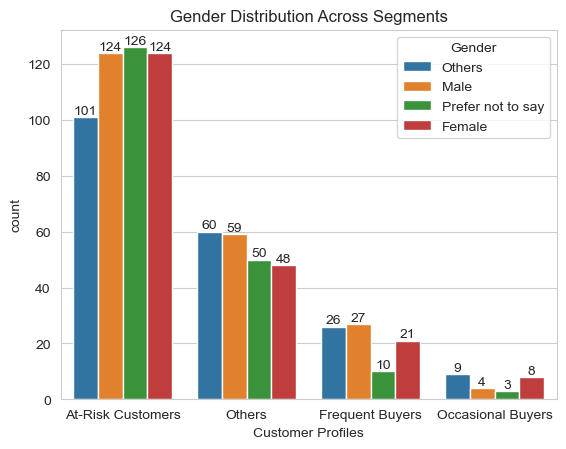

In [80]:
cpg=sns.countplot(x='Customer_profiles', hue='Gender', data=df)
for container in cpg.containers:
    cpg.bar_label(container)
plt.xlabel('Customer Profiles')
plt.title("Gender Distribution Across Segments")
plt.xticks(rotation=0)
plt.show()

#### --> Customer risk (low satisfaction/abandonment) is not gender-specific — it’s a platform-wide issue.
#### --> Frequent Buyers are Balanced Across Genders - Loyal customers exist in all gender groups equally
#### --> Occasional Buyers are Very Low in Every Gender
#### --> Others segments are evenly distributed
#### “High at-risk across all genders → poor customer experience consistency” “Low occasional buyers → weak engagement funnel” “Balanced frequent buyers → broad appeal of platform”

## Task 3.4: Use clustering (e.g., K-Means) for behavioral grouping based on survey responses. 

In [81]:
df.head()

,Age,Gender,Purchase_freq,Purchase_cat,Personalized_recom_freq(cat),Browse_freq,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Imp,Add_to_Cart_Brows,...,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,Recommendation_Helpfulness_Score,Recom_Helpfulness_Score,Age_group,Purchase_freq_score,Customer_Segment,cart_abandon_score,Customer_profiles
0,24,Others,monthly,Clothing and Fashion;others,No,Rarely,Keyword,First page,1,Maybe,...,1,Customer service,I don't have any problem with Amazon,sometimes,2,21-30,2,Not Satisfied and Infrequent Customers,2,At-Risk Customers
1,12,Male,weekly_high,Groceries and Gourmet Food;Beauty and Personal...,No,low,categories,First page,5,No,...,3,Competitive prices,Nil,sometimes,2,11-20,5,Low Value Customers,3,Others
2,14,Prefer not to say,monthly_high,Clothing and Fashion;Home and Kitchen,No,High,Keyword,Multiple pages,2,No,...,2,.,I have no problem with Amazon yet. But others ...,yes,1,11-20,3,Low Value Customers,2,At-Risk Customers
3,51,Female,weekly_high,Beauty and Personal Care;Clothing and Fashion;...,No,High,categories,First page,1,Yes,...,4,Product recommendations,Irrelevant product suggestions,sometimes,2,51-60,5,Loyal Customers,4,Frequent Buyers
4,46,Male,weekly_high,Groceries and Gourmet Food;Beauty and Personal...,No,low,Keyword,First page,4,Yes,...,5,Product recommendations,Add more familiar brands to the list,no,0,41-50,5,Loyal Customers,4,Frequent Buyers


In [82]:
features = ['Purchase_freq_score','Shopping_Satisfaction']
x=df[features]

In [83]:
df[features].isnull().sum()

Purchase_freq_score      0
Shopping_Satisfaction    0
dtype: int64

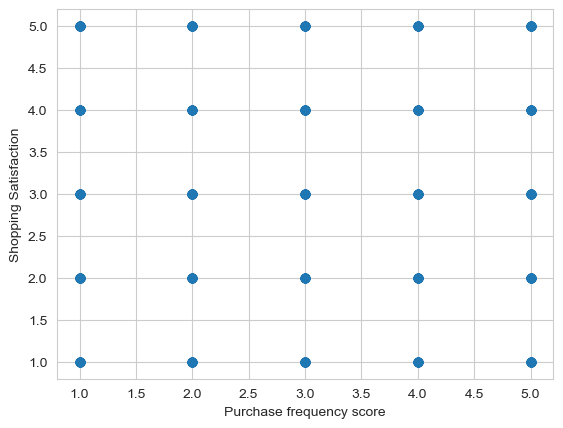

In [84]:
plt.scatter(x['Purchase_freq_score'],x['Shopping_Satisfaction'])
plt.xlabel('Purchase frequency score')
plt.ylabel('Shopping Satisfaction')
plt.show()

WCSS
 [3318.4399999999987, 2032.6556167352578, 1253.6088035925445, 795.446189854609, 696.3234288864301, 552.0615555026511, 454.2052436722441, 448.08638713463324, 329.4343244569047, 331.87362615669963, 291.13135639895063, 230.01559402057092, 201.58537241853344, 189.9360874143258, 155.15854260638753, 151.79428872935512, 125.9436376761222, 103.74527412478241, 99.31820872403401]


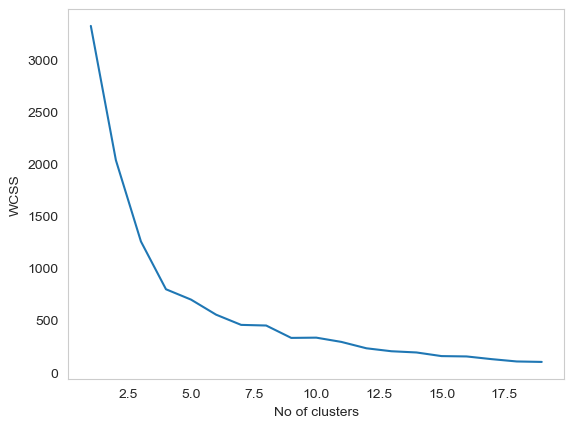

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# wcss = within cluster sum of square
wcss = []
for i in range(1,20): # i = no of clusters,i=1,2,3,...19
    m = KMeans(n_clusters=i)
    m.fit(x)
    wcss.append(m.inertia_)

# Elbow plot between - x axis: no. of Ks(19), y axis: no. of WCSS values
print('WCSS\n',wcss)
plt.plot(list(range(1,20)),wcss)
plt.xlabel('No of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [86]:
for i in range(2,20 ): # i = no of clusters
    m = KMeans(n_clusters=i).fit(x)
    print(f'Silhoutte Score at K={i}',silhouette_score(x,m.labels_))

Silhoutte Score at K=2 0.34438933353674805
Silhoutte Score at K=3 0.40385144105860976
Silhoutte Score at K=4 0.4415417129890071
Silhoutte Score at K=5 0.41869533594086433
Silhoutte Score at K=6 0.4487235021659962
Silhoutte Score at K=7 0.44242998348448553
Silhoutte Score at K=8 0.4737205876613124
Silhoutte Score at K=9 0.4820507497672945
Silhoutte Score at K=10 0.5315890671639305
Silhoutte Score at K=11 0.526129713801464
Silhoutte Score at K=12 0.5413781683025367
Silhoutte Score at K=13 0.5780780393884211
Silhoutte Score at K=14 0.5978726515272927
Silhoutte Score at K=15 0.637757200250646
Silhoutte Score at K=16 0.6441763219777465
Silhoutte Score at K=17 0.6955478253940953
Silhoutte Score at K=18 0.7592959414027141
Silhoutte Score at K=19 0.7894232457208693


#### --> Although silhouette score increased with higher K values, I avoided overfitting by selecting an optimal K in the range of 3–8, balancing cluster quality with interpretability

In [87]:
k5 = KMeans(n_clusters=5)
k5.fit(x)
ypred5 = k5.predict(x)
print(ypred5)

[2 3 0 3 3 2 0 3 3 3 2 0 2 3 1 3 3 3 3 0 1 3 4 1 0 3 1 4 1 2 2 1 3 1 3 2 3
 0 2 0 1 2 4 0 3 1 1 0 4 4 2 0 0 2 3 2 2 0 3 1 4 1 1 0 3 4 0 1 2 1 0 0 4 3
 1 1 3 0 3 0 1 0 0 1 1 0 0 1 3 3 2 1 3 3 3 0 0 3 1 0 3 4 1 0 3 4 2 2 3 2 4
 1 3 1 1 1 0 1 3 1 0 2 4 3 0 0 2 0 0 1 2 2 0 2 2 2 3 1 0 3 0 2 3 0 3 4 4 2
 4 4 1 3 0 0 1 0 0 4 2 1 0 1 4 0 3 0 2 2 1 1 4 3 0 1 0 1 0 0 0 4 0 0 3 1 1
 0 1 1 3 0 0 3 4 0 2 1 4 3 2 0 4 1 0 3 2 0 2 0 0 2 2 2 0 3 3 1 1 0 1 3 0 3
 0 3 1 3 3 3 3 2 0 0 4 0 4 0 3 0 3 2 0 3 2 1 2 1 4 0 2 2 2 0 1 3 0 2 4 0 4
 0 1 2 1 1 4 4 2 0 0 4 0 0 0 3 0 3 2 3 1 3 0 2 1 2 2 0 1 0 4 0 2 1 3 1 2 0
 3 3 3 0 2 2 4 2 0 2 0 4 3 3 3 3 3 0 3 3 3 4 1 2 2 3 3 3 1 0 0 0 2 2 4 3 3
 3 4 2 3 3 0 0 3 0 0 3 2 2 0 1 1 0 2 4 4 4 2 1 2 4 4 0 4 4 0 1 0 3 2 0 3 3
 2 3 0 3 3 0 2 3 2 4 0 1 3 0 3 1 2 0 3 0 3 2 3 0 1 1 3 3 0 3 0 1 0 3 1 0 2
 2 3 0 1 0 3 2 0 1 1 1 3 3 0 2 2 2 1 2 2 0 1 0 0 3 2 2 1 1 4 1 3 1 0 1 3 1
 4 2 0 4 4 1 3 0 1 4 4 4 2 0 4 2 0 4 4 3 2 3 2 3 1 4 4 3 1 2 1 4 0 0 1 1 0
 1 0 0 2 1 1 1 2 4 3 2 3 

In [88]:
from collections import Counter
c1 = Counter(ypred5)
print(c1)

Counter({np.int32(0): 202, np.int32(3): 179, np.int32(2): 164, np.int32(1): 156, np.int32(4): 99})


In [89]:
cent5 = k5.cluster_centers_
print(cent5)

[[4.04455446 1.46039604]
 [2.55769231 3.72435897]
 [1.37195122 1.76829268]
 [4.54748603 3.96648045]
 [1.34343434 4.76767677]]


In [90]:
df['Cls5'] = ypred5

#### A new column was created in the data set, which indicates which customer will come in which group based on purchase frequency score and shopping satisfaction 

In [91]:
cent5 = k5.cluster_centers_
print(cent5)

[[4.04455446 1.46039604]
 [2.55769231 3.72435897]
 [1.37195122 1.76829268]
 [4.54748603 3.96648045]
 [1.34343434 4.76767677]]


#### Then created a scatter plot to visualize the position of mean value of the cluster. 

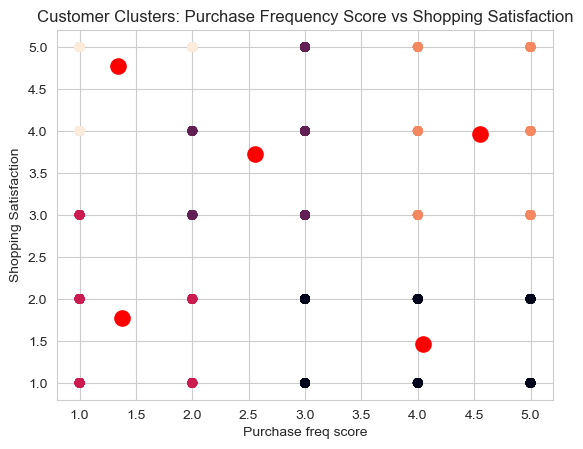

In [92]:
plt.scatter(x['Purchase_freq_score'],x['Shopping_Satisfaction'],c=df['Cls5'])
plt.scatter(cent5[:,0],cent5[:,1],color='red',s=120)
plt.title("Customer Clusters: Purchase Frequency Score vs Shopping Satisfaction")
plt.xlabel('Purchase freq score')
plt.ylabel('Shopping Satisfaction')
plt.show()

#### This scatter plot visualizes customer segments formed using K-Means clustering, based on purchase frequency and satisfaction, with centroids representing the average behavior of each cluster.

In [93]:
res = df[features].groupby(df['Cls5']).mean()
res

,Purchase_freq_score,Shopping_Satisfaction
Cls5,,
0,4.044554,1.460396
1,2.557692,3.724359
2,1.371951,1.768293
3,4.547486,3.966480
4,1.343434,4.767677


In [94]:
res1 = pd.DataFrame({'Purchase_freq_score':df['Purchase_freq_score'].mean(),
                   'Shopping_Satisfaction':df['Shopping_Satisfaction'].mean()},index=['Avg'])
res1

,Purchase_freq_score,Shopping_Satisfaction
Avg,2.985,2.935


In [95]:
profiling = pd.concat([res1,res])
profiling

,Purchase_freq_score,Shopping_Satisfaction
Avg,2.985000,2.935000
0,4.044554,1.460396
1,2.557692,3.724359
2,1.371951,1.768293
3,4.547486,3.966480
4,1.343434,4.767677


#### --> Conclusion : Cluster profiling revealed distinct customer segments based on purchase behavior and satisfaction levels, helping identify loyal customers, at-risk users, and potential growth segments.
#### cls0 - Low Purchase_freq_score; High Shopping_Satisfaction
#### cls1 - High Purchase_freq_score; High Shopping_Satisfaction
#### cls2 - Low Purchase_freq_score; Low Shopping_Satisfaction
#### cls3 - High Purchase_freq_score; Low Shopping_Satisfaction
#### cls4 - High Purchase_freq_score; High Shopping_Satisfaction

# Task 4: Recommendation and Review Insights

## Task 4.1: Examine the relationship between recommendation helpfulness and shopping satisfaction. 

In [96]:
df['Recom_Helpfulness'].unique()

array(['Sometimes', 'Yes', 'No'], dtype=object)

In [97]:
df['Recommendation_Helpfulness_Score'] = df['Recom_Helpfulness'].str.strip().str.lower()
mapping = {
    'yes': 1,
    'sometimes': 2,
    'no': 0
}
df['Recom_Helpfulness_Score'] = df['Recommendation_Helpfulness_Score'].map(mapping)

In [98]:
df['Recom_Helpfulness_Score'].value_counts()

Recom_Helpfulness_Score
2    270
1    265
0    265
Name: count, dtype: int64

In [99]:
df['Recom_Helpfulness_Score'].isnull().sum()

np.int64(0)

In [100]:
df.groupby('Recom_Helpfulness_Score')['Shopping_Satisfaction'].mean()

Recom_Helpfulness_Score
0    2.875472
1    2.950943
2    2.977778
Name: Shopping_Satisfaction, dtype: float64

In [101]:
df['Recom_Helpfulness_Score'].corr(df['Shopping_Satisfaction'])

np.float64(0.029096160369359608)

#### --> The correlation between recommendation helpfulness and shopping satisfaction is very weak, indicating that recommendations currently have minimal impact on overall customer satisfaction
#### --> There is no significant linear relationship between recommendation helpfulness and shopping satisfaction.

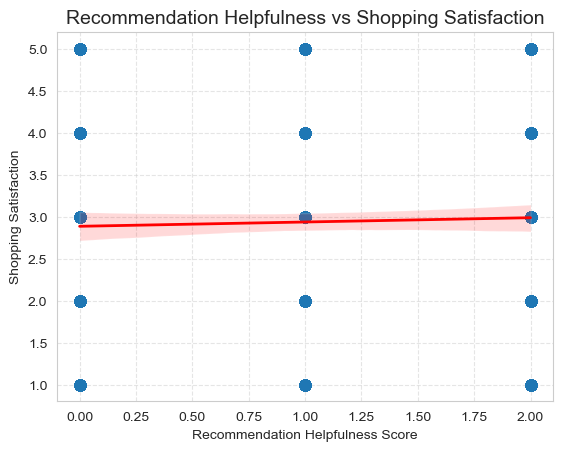

In [102]:
sns.regplot(x='Recom_Helpfulness_Score',y='Shopping_Satisfaction',data=df,scatter_kws={'alpha':0.6, 's':60},
            line_kws={'color':'red', 'linewidth':2})
plt.title("Recommendation Helpfulness vs Shopping Satisfaction", fontsize=14)
plt.xlabel("Recommendation Helpfulness Score")
plt.ylabel("Shopping Satisfaction")
plt.grid(True, linestyle='--', alpha=0.5)

#### --> The regplot indicates no strong correlation between recommendation helpfulness and shopping satisfaction, as satisfaction levels are widely distributed across all levels of recommendation helpfulness. This suggests that other factors beyond recommendations may be influencing customer satisfaction.

## Task 4.2: Evaluate how review reliability and helpfulness impact overall ratings.

In [103]:
df['Review_Reliability'].value_counts()

Review_Reliability
Heavily         170
Rarely          165
Never           163
Moderately      152
Occasionally    150
Name: count, dtype: int64

In [104]:
df['Review_Helpfulness'].value_counts()

Review_Helpfulness
No           282
Sometimes    269
Yes          249
Name: count, dtype: int64

In [105]:
rely_mapping= ({ "Heavily": 4,"Moderately": 3,"Occasionally": 2,"Rarely": 1,"Never": 0})
df['Review_Reliability_Score'] =df['Review_Reliability'].map(rely_mapping)
df['Review_Reliability_Score'].value_counts()

Review_Reliability_Score
4    170
1    165
0    163
3    152
2    150
Name: count, dtype: int64

In [106]:
review__helpfulness_map= ({ "No": 0, "Yes":1, "Sometimes":2})
df['Review_Helpfulness_Score'] = df['Review_Helpfulness'].map(review__helpfulness_map)
df['Review_Helpfulness_Score'].value_counts()

Review_Helpfulness_Score
0    282
2    269
1    249
Name: count, dtype: int64

In [107]:
df.groupby('Review_Reliability')['Rating_Accuracy'].mean()

Review_Reliability
Heavily         3.076471
Moderately      2.940789
Never           3.085890
Occasionally    3.040000
Rarely          3.139394
Name: Rating_Accuracy, dtype: float64

In [108]:
df.groupby('Review_Helpfulness')['Rating_Accuracy'].mean()

Review_Helpfulness
No           3.131206
Sometimes    2.992565
Yes          3.048193
Name: Rating_Accuracy, dtype: float64

In [109]:
df[['Review_Reliability_Score','Review_Helpfulness_Score','Rating_Accuracy']].corr()

,Review_Reliability_Score,Review_Helpfulness_Score,Rating_Accuracy
Review_Reliability_Score,1.000000,-0.047201,-0.020609
Review_Helpfulness_Score,-0.047201,1.000000,-0.040033
Rating_Accuracy,-0.020609,-0.040033,1.000000


#### --> Review reliability and helpfulness have almost no impact on rating accuracy
#### --> As reliability/helpfulness increases, Rating accuracy slightly decreases

Text(0.5, 1.0, 'Correlation between Review Helpfulness, Review reliability and Rating Accuracy')

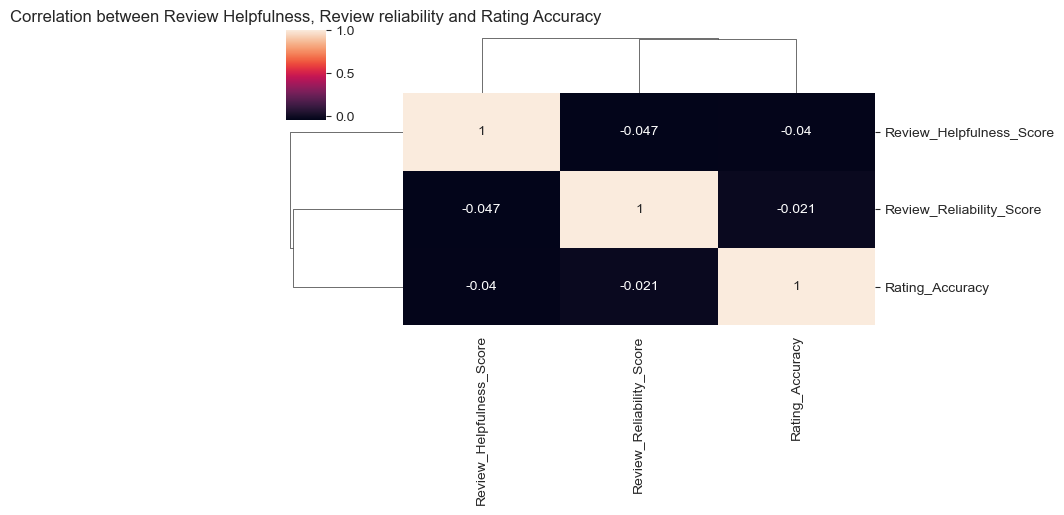

In [110]:
sns.clustermap(df[['Review_Reliability_Score','Review_Helpfulness_Score','Rating_Accuracy']].corr(),figsize=(8, 5),annot=True)
plt.title('Correlation between Review Helpfulness, Review reliability and Rating Accuracy')

#### --> This correlation indicates that there is weak relationship between variables, Also, These factors do not strongly influence each other.
#### --> Customer perception of review reliability, helpfulness, and rating accuracy appears to be largely independent, indicating that improving one factor may not necessarily impact the others.

## Task 4.3: Identify trends in how often customers engage with or trust personalized recommendations. 

In [111]:
df['Personalized_recom_freq(cat)'].value_counts()

Personalized_recom_freq(cat)
No           271
Yes          271
Sometimes    258
Name: count, dtype: int64

In [112]:
df['Recom_Helpfulness'].value_counts()

Recom_Helpfulness
Sometimes    270
Yes          265
No           265
Name: count, dtype: int64

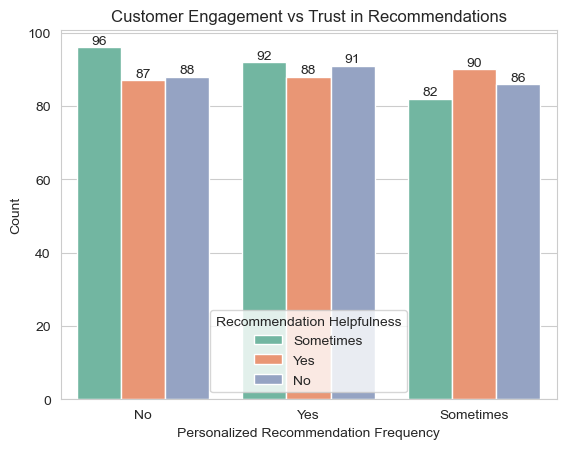

In [113]:
cpg = sns.countplot(x='Personalized_recom_freq(cat)',hue='Recom_Helpfulness',data=df,palette='Set2')
for container in cpg.containers:
    cpg.bar_label(container)
plt.title("Customer Engagement vs Trust in Recommendations")
plt.xlabel("Personalized Recommendation Frequency")
plt.ylabel("Count")
plt.legend(title="Recommendation Helpfulness")
plt.show()

#### --> It tells whether customers who receive more recommendations actually trust and engage with them.
#### --> From the distribution, it is indicated that the personalised recommendation does not really influence the customer engagement and trust towards recommendations. 

Text(0.5, 1.0, 'Correlation between Recommendation Helpfulness and Personalized Recommendation frequency')

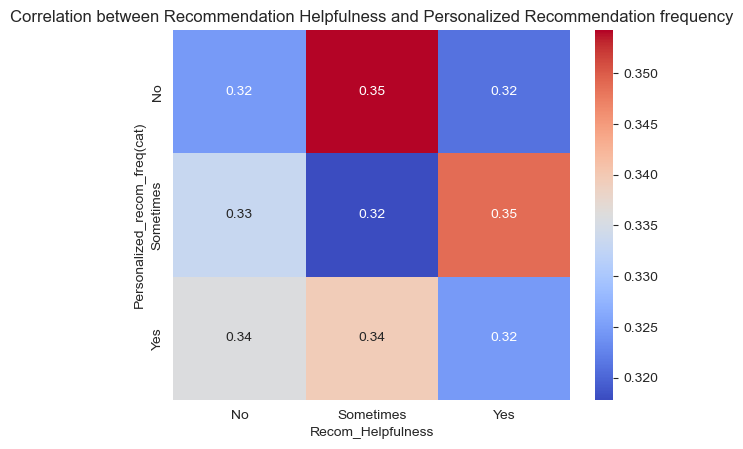

In [114]:
sns.heatmap(pd.crosstab(df['Personalized_recom_freq(cat)'],df['Recom_Helpfulness'],normalize='index'),
annot=True,cmap='coolwarm')
plt.title('Correlation between Recommendation Helpfulness and Personalized Recommendation frequency')

#### The analysis indicates that customer trust in personalized recommendations remains relatively consistent across different levels of engagement. Increasing the frequency of recommendations does not significantly enhance perceived helpfulness, suggesting that relevance and personalization quality are more critical than frequency.

## Recommendations: ✔ Focus on quality, not quantity ✔ Improve recommendation relevance ✔ Avoid excessive recommendations

## Task 4.4: Suggest actionable insights for improving Target’s recommendation system.

### 1. Customers don’t find recommendations significantly helpful → low correlation

### Action: 
### * Use past purchase history,
### * Track browsing behavior
### * Recommend similar or complementary products

### 2. More Recommendations doesn't mean more trust 
### Actions:
### * Limit the number of recommendations per session
### * Show only top 3–5 highly relevant products
### It will improve user experience and perceived usefulness

### To enhance the effectiveness of the recommendation system, the following strategies are suggested:

#### Leverage behavioral data such as past purchase history and browsing patterns to deliver more relevant and personalized recommendations.
#### Adopt a targeted approach by recommending similar or complementary products aligned with customer preferences.
#### Limit the number of recommendations per session to avoid overwhelming users, focusing instead on a curated set of high-quality suggestions (e.g., top 3–5 products).
#### Implement segment-based personalization, tailoring recommendations according to different customer groups and behaviors.
#### Improve transparency and trust signals by incorporating reliable reviews and clearly explaining why products are recommended.

# Task 5: Visualization and Reporting

## Purchase categories

C:\Users\alpan\AppData\Local\Temp\ipykernel_28236\2030281696.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  pct = sns.countplot(y='Purchase_cat',data=df_splitted,order=df_splitted['Purchase_cat'].value_counts().index,palette = 'viridis')


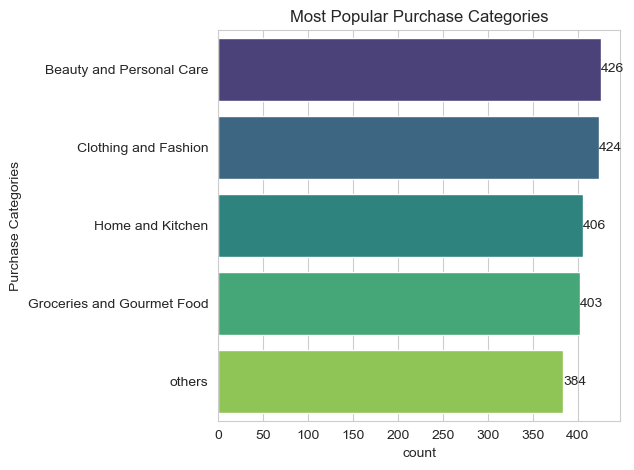

In [115]:
pct = sns.countplot(y='Purchase_cat',data=df_splitted,order=df_splitted['Purchase_cat'].value_counts().index,palette = 'viridis')
for container in pct.containers:
    pct.bar_label(container)
plt.title("Most Popular Purchase Categories")
plt.ylabel('Purchase Categories')
plt.tight_layout()
plt.yticks(rotation=0)
plt.show()

#### --> Most purchases are concentrated in 'Beauty and Personal Care' and 'Clothing and fashion' category
#### --> Indicates strong product demand concentration
#### --> Recommendation: Focus inventory on top-performing categories

## Browsing Frequency Distribution

C:\Users\alpan\AppData\Local\Temp\ipykernel_28236\3853612382.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bfd = sns.barplot(x='Browse_freq', y='Count', data=browse_counts, palette='viridis')


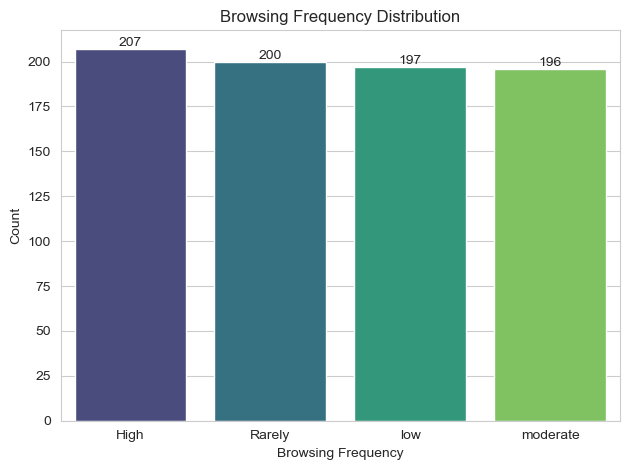

In [116]:
browse_counts = df['Browse_freq'].value_counts().reset_index()
browse_counts.columns = ['Browse_freq', 'Count']
bfd = sns.barplot(x='Browse_freq', y='Count', data=browse_counts, palette='viridis')
for container in bfd.containers:
    bfd.bar_label(container)
plt.title("Browsing Frequency Distribution")
plt.xlabel('Browsing Frequency')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### --> Majority users browse Multiple times a day, 
#### --> Shows active engagement but not always conversion
#### --> Recommendation: Improve conversion strategies

## Satisfaction levels 

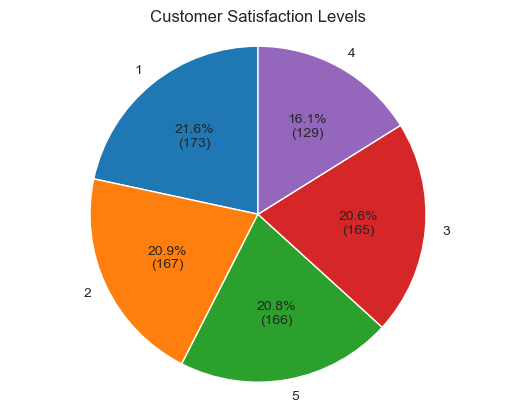

In [117]:
counts = df['Shopping_Satisfaction'].value_counts()
def func(pct, allvalues):
    absolute = int(pct/100. * sum(allvalues))
    return f"{pct:.1f}%\n({absolute})"
plt.pie(counts,labels=counts.index,autopct=lambda pct: func(pct, counts),startangle=90)
plt.title("Customer Satisfaction Levels")
plt.axis('equal')
plt.show()

#### --> Most users fall in moderate to high satisfaction
#### --> Very few highly dissatisfied customers
#### --> Recommendation: Maintain service quality while improving weak areas

## Correlation between recommendation usefulness and satisfaction

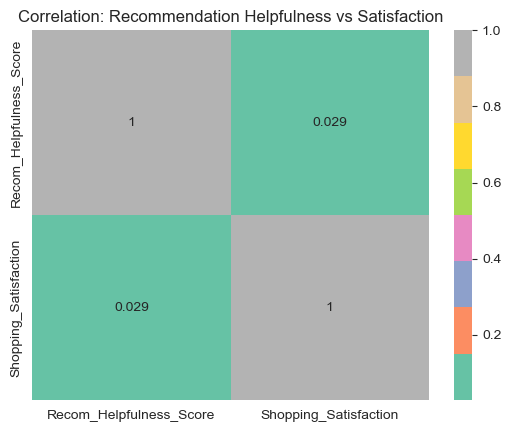

In [118]:
sns.heatmap(df[['Recom_Helpfulness_Score','Shopping_Satisfaction']].corr(),annot=True,cmap='Set2')
plt.title("Correlation: Recommendation Helpfulness vs Satisfaction")
plt.show()


#### --> There is a weak positive correlation (0.029) between recommendation helpfulness and shopping satisfaction.
#### --> This indicates that perceived usefulness or recommendation does not significantly influence customer satisfaction. 
#### Recommendation: Focus on multiple factors such as service quality, pricing, and personalization to enhance overall user experience. 

# Task 6: Video Presentation : 
## Video link: https://www.loom.com/share/8c805eb0d5f94f508559103e62579f9d